## Random Forest Regressor

Loading datasets...
Initial dataset shape: (329535, 9)

Cleaning data...
Shape after cleaning: (258338, 9)

Engineering features...

Handling missing values...
Remaining NaN values per column:


/var/folders/sb/jyxnm30n3_q45d56yy8qh8jm0000gn/T/ipykernel_32601/4092469422.py:102: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_features[col].fillna(global_mean, inplace=True)


tconst                        0
primaryTitle                  0
startYear                     0
runtimeMinutes                0
genres                        0
averageRating                 0
numVotes                      0
directors                     0
writers                       0
writers_id               191702
writers_avg_rating            0
writers_movie_count      191702
directors_id             102010
directors_avg_rating          0
directors_movie_count    102010
Action                        0
Adult                         0
Adventure                     0
Animation                     0
Biography                     0
Comedy                        0
Crime                         0
Documentary                   0
Drama                         0
Family                        0
Fantasy                       0
Film-Noir                     0
Game-Show                     0
History                       0
Horror                        0
Music                         0
Musical 

/var/folders/sb/jyxnm30n3_q45d56yy8qh8jm0000gn/T/ipykernel_32601/4092469422.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


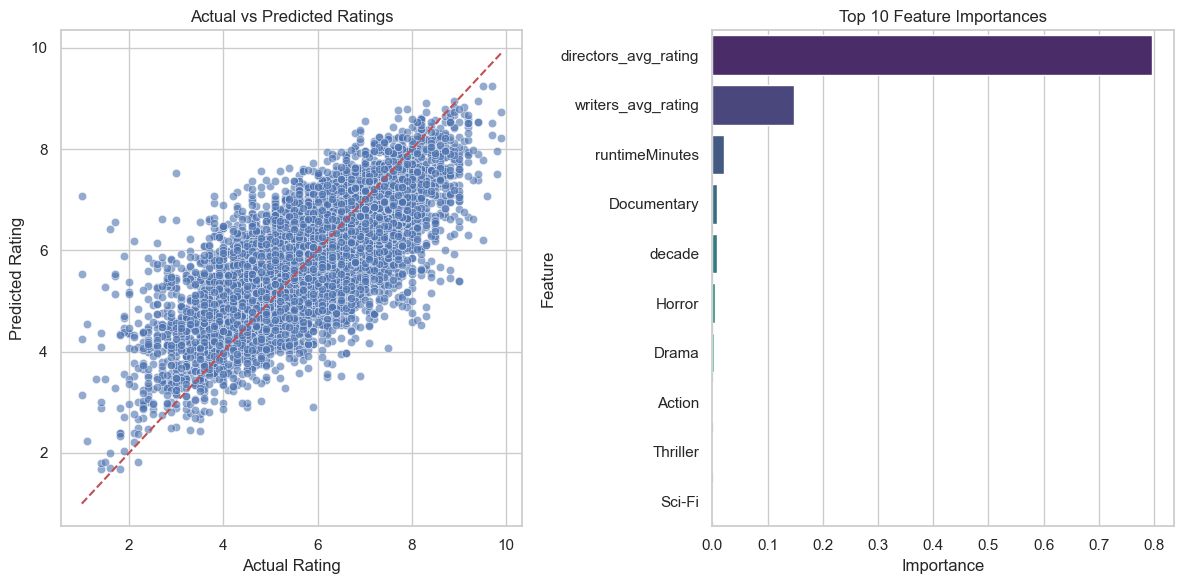

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# ======================
# 1. DATA LOADING
# ======================
print("Loading datasets...")
try:
    # Load IMDb datasets
    basics = pd.read_csv("title.basics.tsv", sep='\t', na_values='\\N', low_memory=False)
    ratings = pd.read_csv("title.ratings.tsv", sep='\t', na_values='\\N')
    crew = pd.read_csv("title.crew.tsv", sep='\t', na_values='\\N')
    
    # Filter for movies only
    movies = basics[basics['titleType'] == 'movie'].copy()
    movies = movies[['tconst', 'primaryTitle', 'startYear', 'runtimeMinutes', 'genres']]
    
    # Merge all data
    movie_data = movies.merge(ratings, on='tconst').merge(crew, on='tconst')
    print(f"Initial dataset shape: {movie_data.shape}")
    
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    exit()

# ======================
# 2. DATA CLEANING
# ======================
print("\nCleaning data...")

# Convert runtime to numeric and drop invalid
movie_data['runtimeMinutes'] = pd.to_numeric(movie_data['runtimeMinutes'], errors='coerce')
movie_data = movie_data.dropna(subset=['runtimeMinutes'])

# Filter for reasonable runtime values (10min - 4hrs)
movie_data = movie_data[(movie_data['runtimeMinutes'] >= 10) & 
                       (movie_data['runtimeMinutes'] <= 240)]

# Convert year to numeric and drop invalid
movie_data['startYear'] = pd.to_numeric(movie_data['startYear'], errors='coerce')
movie_data = movie_data.dropna(subset=['startYear'])

# Drop rows missing essential fields
movie_data = movie_data.dropna(subset=['writers', 'directors', 'genres'])

print(f"Shape after cleaning: {movie_data.shape}")

# ======================
# 3. FEATURE ENGINEERING
# ======================
print("\nEngineering features...")

def get_contributor_stats(df, id_col, rating_col='averageRating', min_movies=3):
    # Explode multiple contributors
    df_exp = df.assign(contributor=df[id_col].str.split(',')).explode('contributor')
    
    # Calculate stats
    stats = df_exp.groupby('contributor')[rating_col].agg(['mean', 'count']).reset_index()
    stats.columns = [f'{id_col}_id', f'{id_col}_avg_rating', f'{id_col}_movie_count']
    
    # Filter for reliable contributors
    return stats[stats[f'{id_col}_movie_count'] >= min_movies]

# Calculate writer/director stats
writer_stats = get_contributor_stats(movie_data, 'writers')
director_stats = get_contributor_stats(movie_data, 'directors')

# Merge stats back to main dataset
movie_features = (movie_data
                 .merge(writer_stats, 
                        left_on='writers', 
                        right_on='writers_id', 
                        how='left')
                 .merge(director_stats, 
                        left_on='directors', 
                        right_on='directors_id', 
                        how='left'))

# Create genre dummies (one-hot encoding)
genres_dummies = movie_features['genres'].str.get_dummies(',')
movie_features = pd.concat([movie_features, genres_dummies], axis=1)

# Add decade feature
movie_features['decade'] = (movie_features['startYear'] // 10) * 10

# ======================
# 4. HANDLE MISSING VALUES
# ======================
print("\nHandling missing values...")

# Fill missing writer/director ratings with global mean
global_mean = movie_features['averageRating'].mean()
for col in ['writers_avg_rating', 'directors_avg_rating']:
    movie_features[col].fillna(global_mean, inplace=True)

# Final check for any remaining NaN values
print("Remaining NaN values per column:")
print(movie_features.isna().sum())

# Drop any rows that might still have NaN values (shouldn't be any after above steps)
movie_features = movie_features.dropna()

print(f"Final dataset shape: {movie_features.shape}")

# ======================
# 5. MODEL TRAINING
# ======================
print("\nPreparing for model training...")

# Define features and target
features = [
    'runtimeMinutes',
    'writers_avg_rating',
    'directors_avg_rating',
    'decade'
] + list(genres_dummies.columns)

X = movie_features[features]
y = movie_features['averageRating']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train model
print("Training Random Forest model...")
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# ======================
# 6. MODEL EVALUATION
# ======================
print("\nEvaluating model...")

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# ======================
# 7. VISUALIZATION
# ======================
plt.figure(figsize=(12, 6))

# Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings')

# Feature Importance
plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

## Neural Network

2025-05-18 16:20:01.896402: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading and preprocessing data...
Engineering features...


/var/folders/sb/jyxnm30n3_q45d56yy8qh8jm0000gn/T/ipykernel_32601/3188177584.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_features['writers_avg_rating'].fillna(global_mean, inplace=True)
/var/folders/sb/jyxnm30n3_q45d56yy8qh8jm0000gn/T/ipykernel_32601/3188177584.py:64: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

Building DNN model...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model...
Epoch 1/100
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 4.0081 - mae: 1.4089 - val_loss: 1.1432 - val_mae: 0.8102
Epoch 2/100
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 1.2730 - mae: 0.8671 - val_loss: 1.1086 - val_mae: 0.7924
Epoch 3/100
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 1.1516 - mae: 0.8177 - val_loss: 1.0722 - val_mae: 0.7753
Epoch 4/100
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.1031 - mae: 0.7958 - val_loss: 1.0537 - val_mae: 0.7662
Epoch 5/100
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 1.0821 - mae: 0.7866 - val_loss: 1.0466 - val_mae: 0.7633
Epoch 6/100
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 1.0695 - mae: 0.7805 - val_loss: 1.0398 - val_mae: 0.7615
Epoch 7/100
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 1.0640 - mae: 0.7790 - val_loss: 1.0376 - val_mae: 0.7602
Epoch 8/100
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 1.0585 - mae: 0.7759 - val_loss: 1.0345 - val_mae: 0.7586
Epoch 

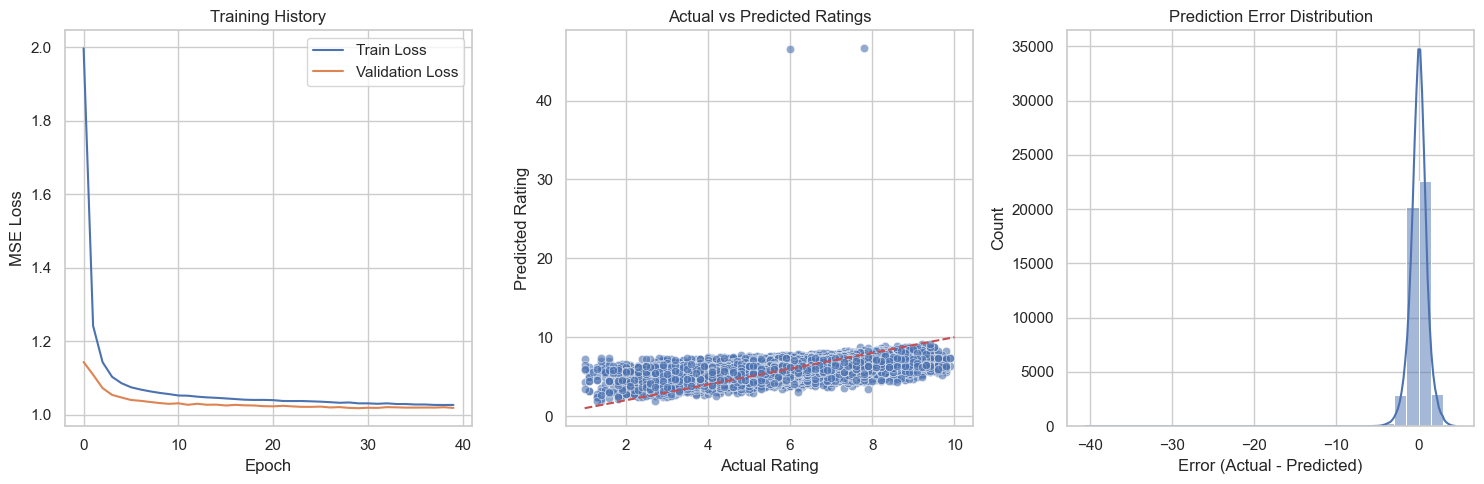

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ======================
# 1. DATA LOADING & CLEANING 
# (Same as Random Forest version)
# ======================
print("Loading and preprocessing data...")

# Load datasets
basics = pd.read_csv("title.basics.tsv", sep='\t', na_values='\\N', low_memory=False)
ratings = pd.read_csv("title.ratings.tsv", sep='\t', na_values='\\N')
crew = pd.read_csv("title.crew.tsv", sep='\t', na_values='\\N')

# Filter for movies
movies = basics[basics['titleType'] == 'movie'].copy()
movies = movies[['tconst', 'primaryTitle', 'startYear', 'runtimeMinutes', 'genres']]

# Merge datasets
movie_data = movies.merge(ratings, on='tconst').merge(crew, on='tconst')

# Clean data
movie_data['runtimeMinutes'] = pd.to_numeric(movie_data['runtimeMinutes'], errors='coerce')
movie_data = movie_data.dropna(subset=['runtimeMinutes', 'writers', 'directors', 'genres', 'startYear'])
movie_data = movie_data[(movie_data['runtimeMinutes'] >= 60) & (movie_data['runtimeMinutes'] <= 240)]
movie_data['startYear'] = pd.to_numeric(movie_data['startYear'], errors='coerce')

# ======================
# 2. FEATURE ENGINEERING
# ======================
print("Engineering features...")

def get_contributor_stats(df, id_col, rating_col='averageRating', min_movies=3):
    df_exp = df.assign(contributor=df[id_col].str.split(',')).explode('contributor')
    stats = df_exp.groupby('contributor')[rating_col].agg(['mean', 'count']).reset_index()
    stats.columns = [f'{id_col}_id', f'{id_col}_avg_rating', f'{id_col}_movie_count']
    return stats[stats[f'{id_col}_movie_count'] >= min_movies]

# Get writer/director stats
writer_stats = get_contributor_stats(movie_data, 'writers')
director_stats = get_contributor_stats(movie_data, 'directors')

# Merge features
movie_features = (movie_data
                .merge(writer_stats, left_on='writers', right_on='writers_id', how='left')
                .merge(director_stats, left_on='directors', right_on='directors_id', how='left'))

# Handle missing values
global_mean = movie_features['averageRating'].mean()
movie_features['writers_avg_rating'].fillna(global_mean, inplace=True)
movie_features['directors_avg_rating'].fillna(global_mean, inplace=True)

# Genre one-hot encoding
genres_dummies = movie_features['genres'].str.get_dummies(',')
movie_features = pd.concat([movie_features, genres_dummies], axis=1)

# Temporal features
movie_features['years_since_release'] = 2023 - movie_features['startYear']  # Update year as needed
movie_features['decade'] = (movie_features['startYear'] // 10) * 10

# ======================
# 3. DATA PREPARATION
# ======================
# Select features and target
features = [
    'runtimeMinutes',
    'writers_avg_rating',
    'directors_avg_rating',
    'years_since_release'
] + list(genres_dummies.columns)

X = movie_features[features]
y = movie_features['averageRating']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ======================
# 4. DNN MODEL ARCHITECTURE
# ======================
print("Building DNN model...")

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Linear output for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# ======================
# 5. TRAINING
# ======================
print("Training model...")
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ======================
# 6. EVALUATION
# ======================
print("\nEvaluating model...")
y_pred = model.predict(X_test_scaled).flatten()

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# ======================
# 7. VISUALIZATION
# ======================
plt.figure(figsize=(15, 5))

# Training history
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

# Actual vs Predicted
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings')

# Error distribution
plt.subplot(1, 3, 3)
errors = y_test - y_pred
sns.histplot(errors, kde=True, bins=30)
plt.title('Prediction Error Distribution')
plt.xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

## Improved Neural Network

/var/folders/sb/jyxnm30n3_q45d56yy8qh8jm0000gn/T/ipykernel_32601/1107122398.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_features['writers_avg_rating'].fillna(global_mean, inplace=True)
/var/folders/sb/jyxnm30n3_q45d56yy8qh8jm0000gn/T/ipykernel_32601/1107122398.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

Epoch 1/20
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 1.0321 - mae: 0.9476 - val_loss: 0.4516 - val_mae: 0.7317 - learning_rate: 0.0015
Epoch 2/20
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.4787 - mae: 0.7782 - val_loss: 0.4336 - val_mae: 0.7255 - learning_rate: 0.0015
Epoch 3/20
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.4513 - mae: 0.7597 - val_loss: 0.4161 - val_mae: 0.7234 - learning_rate: 0.0015
Epoch 4/20
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.4282 - mae: 0.7464 - val_loss: 0.3975 - val_mae: 0.7083 - learning_rate: 0.0015
Epoch 5/20
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.4102 - mae: 0.7358 - val_loss: 0.3912 - val_mae: 0.7098 - learning_rate: 0.0015
Epoch 6/20
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.4033 - mae: 0.7323 - val_loss: 0.3959 - val_mae: 0.7201 - learning_rate: 0.0015
Epoch 7/20
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.4010 - mae: 0.7311 - val_loss: 0.3865 - val_mae: 0.7039 - learnin

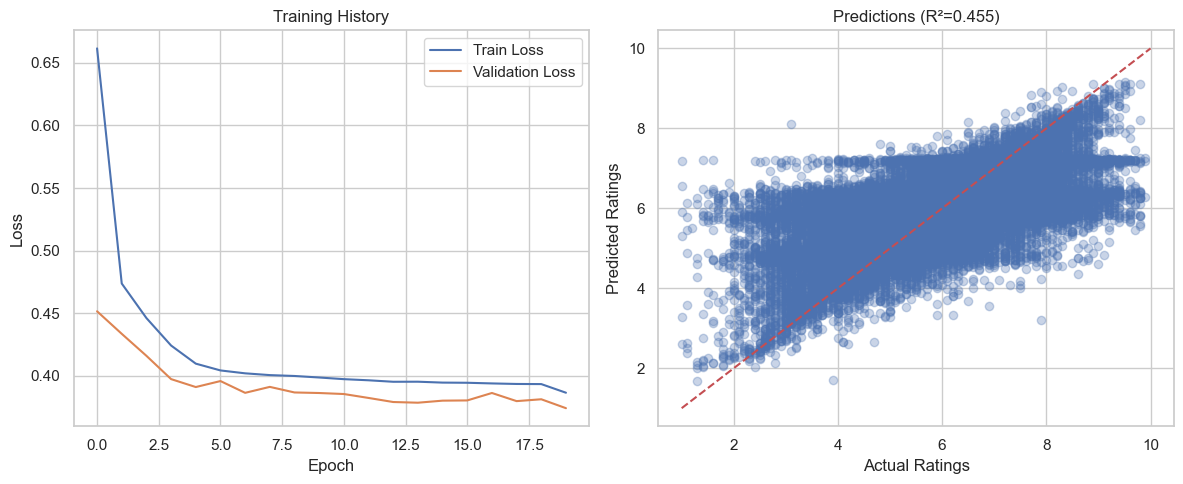

In [19]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

def load_and_engineer_features():
    # Load datasets
    basics = pd.read_csv("title.basics.tsv", sep='\t', na_values='\\N', low_memory=False)
    ratings = pd.read_csv("title.ratings.tsv", sep='\t', na_values='\\N')
    crew = pd.read_csv("title.crew.tsv", sep='\t', na_values='\\N')
    
    # Filter for movies
    movies = basics[basics['titleType'] == 'movie'].copy()
    movies = movies[['tconst', 'primaryTitle', 'startYear', 'runtimeMinutes', 'genres']]
    
    # Merge datasets
    movie_data = movies.merge(ratings, on='tconst').merge(crew, on='tconst')
    
    # Clean data
    movie_data['runtimeMinutes'] = pd.to_numeric(movie_data['runtimeMinutes'], errors='coerce')
    movie_data = movie_data.dropna(subset=['runtimeMinutes', 'writers', 'directors', 'genres', 'startYear'])
    movie_data = movie_data[(movie_data['runtimeMinutes'] >= 60) & (movie_data['runtimeMinutes'] <= 240)]
    movie_data['startYear'] = pd.to_numeric(movie_data['startYear'], errors='coerce')
    
    # Feature engineering
    def get_contributor_stats(df, id_col, rating_col='averageRating', min_movies=3):
        df_exp = df.assign(contributor=df[id_col].str.split(',')).explode('contributor')
        stats = df_exp.groupby('contributor')[rating_col].agg(['mean', 'count']).reset_index()
        stats.columns = [f'{id_col}_id', f'{id_col}_avg_rating', f'{id_col}_movie_count']
        return stats[stats[f'{id_col}_movie_count'] >= min_movies]
    
    writer_stats = get_contributor_stats(movie_data, 'writers')
    director_stats = get_contributor_stats(movie_data, 'directors')
    
    movie_features = (movie_data
                    .merge(writer_stats, left_on='writers', right_on='writers_id', how='left')
                    .merge(director_stats, left_on='directors', right_on='directors_id', how='left'))
    
    # Handle missing values
    global_mean = movie_features['averageRating'].mean()
    movie_features['writers_avg_rating'].fillna(global_mean, inplace=True)
    movie_features['directors_avg_rating'].fillna(global_mean, inplace=True)
    
    # Create genre dummies
    genres_dummies = movie_features['genres'].str.get_dummies(',')
    movie_features = pd.concat([movie_features, genres_dummies], axis=1)
    
    # Temporal features
    movie_features['years_since_release'] = 2023 - movie_features['startYear']
    movie_features['decade'] = (movie_features['startYear'] // 10) * 10
    
    # Crew collaboration feature
    movie_features['crew_combo'] = movie_features['directors_id'].fillna('unknown') + "_" + movie_features['writers_id'].fillna('unknown')
    combo_stats = movie_features.groupby('crew_combo')['averageRating'].mean().reset_index()
    combo_stats.columns = ['crew_combo', 'crew_combo_avg']
    movie_features = movie_features.merge(combo_stats, on='crew_combo', how='left')
    movie_features['crew_combo_avg'].fillna(global_mean, inplace=True)
    
    # Select features
    features = [
        'runtimeMinutes', 
        'writers_avg_rating', 
        'directors_avg_rating',
        'years_since_release',
        'decade',
        'crew_combo_avg'
    ] + [col for col in genres_dummies.columns if col in movie_features.columns]
    
    X = movie_features[features]
    y = movie_features['averageRating']
    
    return X, y

# Load data
X, y = load_and_engineer_features()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build optimized model
def build_optimized_model(input_shape):
    model = Sequential([
        Dense(256, activation='relu', input_shape=input_shape,
              kernel_regularizer=regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(0.1),
        Dense(128, activation='relu',
              kernel_regularizer=regularizers.l2(0.005)),
        BatchNormalization(),
        Dropout(0.05),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.0015),
        loss=Huber(),  # Correct way to specify Huber loss
        metrics=['mae']
    )
    return model

model = build_optimized_model((X_train_scaled.shape[1],))

# Train with callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# Evaluate
y_pred = model.predict(X_test_scaled).flatten()
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nModel Performance:")
print(f"- R²: {r2:.4f}")
print(f"- MSE: {mse:.4f}")
print(f"- MAE: {mae:.4f}")

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title(f'Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()